AAI-2505 Rakhmetulina Assylzhan

 # License Plate Corner Keypoint Detection Using Deep Learning

 This project focuses on developing a deep learning model to detect the four
 corner keypoints of vehicle license plates in images. Keypoint detection is a
 computer vision task that aims to identify specific landmark points within an
 image. In this task, the goal is to accurately localize the four vertices of a license
 plate, which is essential for geometric alignment and precise image analysis.
 The data set used in this project contains vehicle images with annotated co
ordinates for the four corners of the license plate. It is presplit into subsets train
 and val. The train subset is utilized for both model training and internal vali
dation during optimization, while the val subset is reserved exclusively for final
 testing and performance evaluation. The dataset can be accessed at: https://
 drive.google.com/file/d/1ugPDQCB4zB0dySc3dLUFDHDV9FlgK_8I/view?usp=
 sharing

 The project explores convolutional neural network (CNN) and transformer
based architectures for keypoint regression and evaluates their performance un
der varying imaging conditions such as changes in illumination, perspective, and
 partial occlusion.

Evaluation Metrics

 The evaluation metrics include:

 • Object Keypoint Similarity (OKS)– provides a scale- and visibility
aware similarity score between predicted and actual keypoints.

 Objectives

 • Develop a deep learning model to accurately detect the four corner key
points of license plates.

 • Assess model robustness under diverse imaging conditions.

 Expected Outcome

 A trained deep learning model capable of reliably detecting the four corner
 keypoints of license plates from real-world vehicle images, providing accurate
 geometric localization and normalization suitable for automated visual analysis
 systems.

 Project Organization

 • This is an individual project.

 • Quantitatively evaluate model performance using OKS metric.

 • Prepare a short report (2 page max) with your results and methods.

In [1]:
!pip install -q gdown albumentations timm==0.6.13

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 549.1/549.1 kB 36.1 MB/s eta 0:00:00


In [2]:
import os
import math
import json
from pathlib import Path
from typing import Tuple, List


import numpy as np
import pandas as pd
from PIL import Image


import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models


import albumentations as A
from albumentations.pytorch import ToTensorV2


import timm

In [3]:
def mount_drive():
  from google.colab import drive
  drive.mount('/content/drive')

In [4]:
GDRIVE_FILE_ID = '1ugPDQCB4zB0dySc3dLUFDHDV9FlgK_8I'


def download_to_drive(dest_folder: str = '/content/drive/MyDrive/license_plate_dataset'):
  mount_drive()
  os.makedirs(dest_folder, exist_ok=True)
  out_path = os.path.join(dest_folder, 'dataset.zip')
  if os.path.exists(out_path) and os.path.getsize(out_path) > 100:
    print('Archive already exists at', out_path)
    return out_path
  try:
    import gdown
  except Exception:
    print('Installing gdown...')
    os.system('pip install -q gdown')
    import gdown
  url = f'https://drive.google.com/uc?id={GDRIVE_FILE_ID}'
  print('Downloading to', out_path)
  gdown.download(url, out_path, quiet=False)
  return out_path

In [ ]:
def extract_archive(archive_path: str, extract_to: str = None):
  extract_to = extract_to or os.path.dirname(archive_path)
  print('Extracting', archive_path, '->', extract_to)
  if archive_path.endswith('.zip'):
    import zipfile
    with zipfile.ZipFile(archive_path, 'r') as z:
      z.extractall(extract_to)
  elif archive_path.endswith(('.tar.gz', '.tgz')):
    import tarfile
    with tarfile.open(archive_path, 'r:gz') as t:
      t.extractall(extract_to)
  else:
    print('Unknown archive format. You may need to extract manually.')

In [ ]:
mount_drive()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
archive = download_to_drive('/content/drive/MyDrive/license_plate_dataset')
extract_archive(archive, '/content/drive/MyDrive/license_plate_dataset')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Downloading...
From (original): https://drive.google.com/uc?id=1ugPDQCB4zB0dySc3dLUFDHDV9FlgK_8I
From (redirected): https://drive.google.com/uc?id=1ugPDQCB4zB0dySc3dLUFDHDV9FlgK_8I&confirm=t&uuid=2787d70f-9d90-499f-a290-2af37772135d
To: /content/drive/MyDrive/license_plate_dataset/dataset.zip
100%|██████████| 1.75G/1.75G [00:17<00:00, 100MB/s]


Extracting /content/drive/MyDrive/license_plate_dataset/dataset.zip -> /content/drive/MyDrive/license_plate_dataset


In [5]:
!ls /content/drive/MyDrive/license_plate_dataset

dataset.zip  plate_dataset_keypoints


In [6]:
!ls /content/drive/MyDrive/license_plate_dataset/plate_dataset_keypoints/

images	keypoints.yaml	labels


In [7]:
!ls /content/drive/MyDrive/license_plate_dataset/plate_dataset_keypoints/labels

train  train.cache  val  val.cache


In [12]:
import os
import cv2
import yaml
import torch
import timm
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torch import nn, optim
from tqdm import tqdm
from torchvision import transforms
import re
import matplotlib.pyplot as plt
import random
from pathlib import Path

In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [34]:
print(torch.cuda.is_available(), torch.cuda.get_device_name(0))

True Tesla T4


In [46]:
!cp -r /content/drive/MyDrive/license_plate_dataset /content/

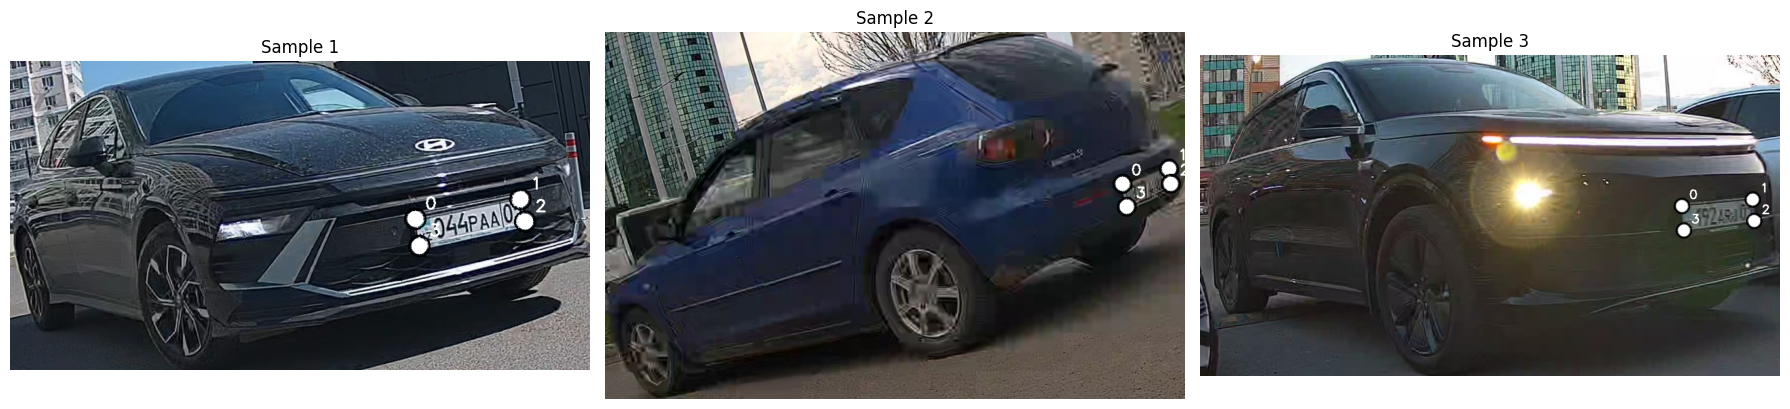

In [47]:
train_images = list(Path("/content/license_plate_dataset/plate_dataset_keypoints/images/train").glob("*.jpg"))
sample_paths = random.sample(train_images, min(3, len(train_images)))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, img_path in enumerate(sample_paths):
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    label_path = Path("/content/license_plate_dataset/plate_dataset_keypoints/labels/train") / (img_path.stem + ".txt")
    with open(label_path, 'r') as f:
        values = f.read().strip().split()

    img_vis = img_rgb.copy()
    for i in range(4):
        idx_kp = 5 + i*3
        kp_x = int(float(values[idx_kp]) * w)
        kp_y = int(float(values[idx_kp+1]) * h)

        cv2.circle(img_vis, (kp_x, kp_y), 12, (255, 255, 255), -1)
        cv2.circle(img_vis, (kp_x, kp_y), 15, (0, 0, 0), 2)
        cv2.putText(img_vis, str(i), (kp_x+15, kp_y-15),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

    axes[idx].imshow(img_vis)
    axes[idx].set_title(f"Sample {idx+1}", fontsize=12)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [48]:
class LicensePlateKeypointDataset(Dataset):
    def __init__(self, images_dir, labels_dir, transform=None, img_size=256):
        self.images_dir = Path(images_dir)
        self.labels_dir = Path(labels_dir)
        self.img_size = img_size
        self.transform = transform
        self.samples = []
        for img_path in self.images_dir.glob("*.jpg"):
            label_path = self.labels_dir / (img_path.stem + ".txt")
            if label_path.exists():
                self.samples.append((img_path, label_path))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label_path = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        with open(label_path, 'r') as f:
            values = f.read().strip().split()
        keypoints = []

        for i in range(4):
            kp_x = float(values[5 + i*3])
            kp_y = float(values[5 + i*3 + 1])
            keypoints.append(kp_x)
            keypoints.append(kp_y)
        keypoints = torch.tensor(keypoints, dtype=torch.float32)
        return image, keypoints

In [49]:
img_size = 256
epochs = 25
batch_size = 16
backbone = "mobilenetv3_large_100"
save_dir = "/content/license_plate_models"

In [50]:
data_root = "/content/license_plate_dataset/plate_dataset_keypoints"
train_img_dir = os.path.join(data_root, "images", "train")
val_img_dir   = os.path.join(data_root, "images", "val")
train_lbl_dir = os.path.join(data_root, "labels", "train")
val_lbl_dir   = os.path.join(data_root, "labels", "val")

In [51]:
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
])
train_ds = LicensePlateKeypointDataset(train_img_dir, train_lbl_dir, transform)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)

val_ds = LicensePlateKeypointDataset(val_img_dir, val_lbl_dir, transform)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

In [52]:
os.makedirs(save_dir, exist_ok=True)

In [54]:
class KeypointModel(nn.Module):
    def __init__(self, backbone_name="mobilenetv3_large_100", num_keypoints=4):
        super().__init__()
        self.backbone = timm.create_model(backbone_name, pretrained=True, num_classes=0)
        in_features = self.backbone.num_features
        self.head = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Linear(512, num_keypoints * 2)
        )

    def forward(self, x):
        features = self.backbone(x)
        out = self.head(features)
        return out


model = KeypointModel(backbone_name=backbone).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [55]:
for param in model.backbone.parameters():
    param.requires_grad = False

In [56]:
def train_model(model, train_loader, val_loader, epochs):
    scaler = torch.amp.GradScaler('cuda')
    early_stop_epochs = 5
    best_val_loss = float('inf')
    bad_epochs = 0

    for epoch in range(epochs):
        if epoch == 5:
            print("Unfreezing backbone for fine-tuning...")
            for param in model.backbone.parameters():
                param.requires_grad = True

        model.train()
        train_loss = 0.0
        for imgs, kps in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            imgs, kps = imgs.to(device, non_blocking=True), kps.to(device, non_blocking=True)
            optimizer.zero_grad()

            with torch.amp.autocast('cuda'):
                preds = model(imgs)
                loss = criterion(preds, kps)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()

        val_loss = 0.0
        model.eval()
        with torch.no_grad():
            for imgs, kps in val_loader:
                imgs, kps = imgs.to(device, non_blocking=True), kps.to(device, non_blocking=True)
                preds = model(imgs)
                val_loss += criterion(preds, kps).item()

        print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f}")

        if (epoch + 1) % 5 == 0 or val_loss < best_val_loss:
            torch.save(model.state_dict(), os.path.join(save_dir, f"mobilenetv3_epoch{epoch+1}.pth"))

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= early_stop_epochs:
                print(f"Stopping early at epoch {epoch+1}")
                break

train_model(model, train_loader, val_loader, epochs)

Epoch 1/25: 100%|██████████| 641/641 [01:32<00:00,  6.92it/s]


Epoch [1/25] Train Loss: 0.0232 | Val Loss: 0.0169


Epoch 2/25: 100%|██████████| 641/641 [01:22<00:00,  7.74it/s]


Epoch [2/25] Train Loss: 0.0099 | Val Loss: 0.0152


Epoch 3/25: 100%|██████████| 641/641 [01:24<00:00,  7.61it/s]


...

Epoch [23/25] Train Loss: 0.0002 | Val Loss: 0.0089


Epoch 24/25: 100%|██████████| 641/641 [01:34<00:00,  6.79it/s]


Epoch [24/25] Train Loss: 0.0003 | Val Loss: 0.0096


Epoch 25/25: 100%|██████████| 641/641 [01:35<00:00,  6.70it/s]


Epoch [25/25] Train Loss: 0.0002 | Val Loss: 0.0092


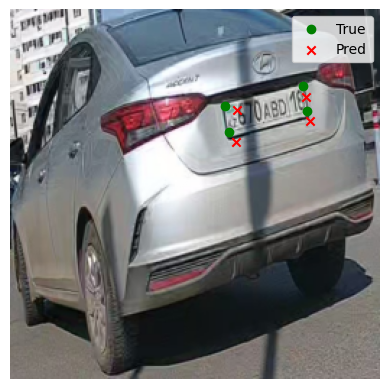

In [59]:
import matplotlib.pyplot as plt

def visualize_keypoints(image, true_kps, pred_kps, img_size=256):
    plt.imshow(image)
    true_kps = true_kps.reshape(-1, 2) * img_size
    pred_kps = pred_kps.reshape(-1, 2) * img_size
    plt.scatter(true_kps[:, 0], true_kps[:, 1], c='g', label='True', marker='o')
    plt.scatter(pred_kps[:, 0], pred_kps[:, 1], c='r', label='Pred', marker='x')
    plt.legend()
    plt.axis('off')
    plt.show()

model.eval()
img, true_kps = val_ds[0]
with torch.no_grad():
    pred_kps = model(img.unsqueeze(0).to(device)).cpu().numpy()[0]
visualize_keypoints(img.permute(1,2,0).numpy(), true_kps.numpy(), pred_kps, img_size=256)

In [64]:
from tqdm import tqdm


checkpoint_path = "/content/license_plate_models/mobilenetv3_epoch25.pth"
img_size = 256
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def compute_oks_per_image_with_vis(pred, gt, vis, image_area, sigmas=None):
    pred = pred.reshape(-1,2)
    gt = gt.reshape(-1,2)
    vis = np.array(vis).astype(bool)
    if sigmas is None:
        sigmas = np.array([0.1]*4)
    vars = (sigmas * 2)**2
    d2 = np.sum((pred - gt)**2, axis=1)
    exp_term = np.exp(-d2 / (2 * vars * (image_area + 1e-6)))
    if vis.sum() == 0:
        return 0.0
    oks = np.sum(exp_term * vis) / np.sum(vis)
    return float(oks)

model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.to(device)
model.eval()

oks_list = []
with torch.no_grad():
    for imgs, kps in tqdm(val_loader, desc="Computing OKS"):
        imgs = imgs.to(device)
        preds = model(imgs)
        preds = preds.cpu().numpy()
        gts = kps.cpu().numpy()

        for p, g in zip(preds, gts):
            pred_px = (p.reshape(-1,2) * img_size).reshape(-1)  # [x1,y1,...] в пикселях
            gt_px   = (g.reshape(-1,2) * img_size).reshape(-1)
            image_area = float(img_size * img_size)
            # Assuming all keypoints are visible (np.ones(4) for 4 keypoints)
            oks = compute_oks_per_image_with_vis(pred_px, gt_px, np.ones(4), image_area)
            oks_list.append(oks)

mean_oks = float(np.mean(oks_list))
print(f"Mean OKS on validation set: {mean_oks:.4f} (N = {len(oks_list)})")


Computing OKS:   0%|          | 0/72 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Computing OKS: 100%|██████████| 72/72 [00:09<00:00,  7.26it/s]

Mean OKS on validation set: 0.8266 (N = 1140)


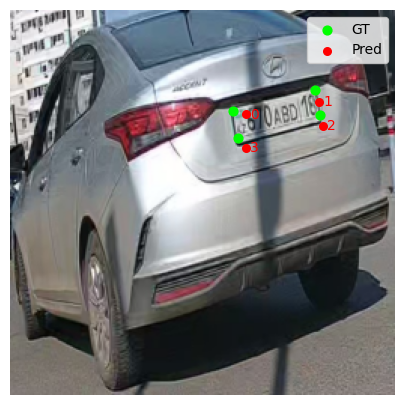

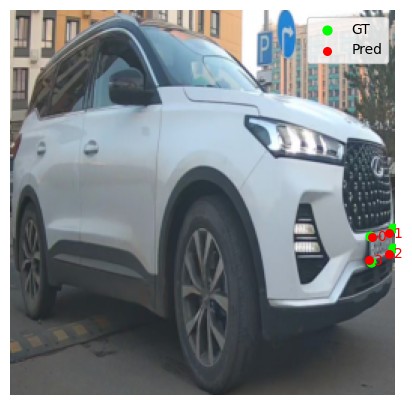

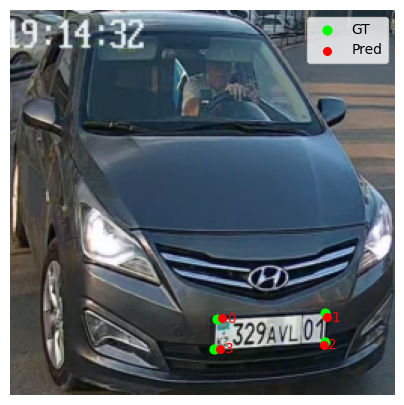

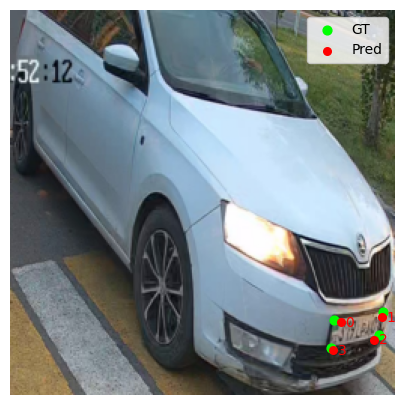

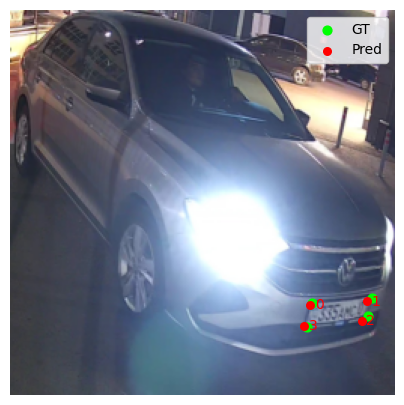

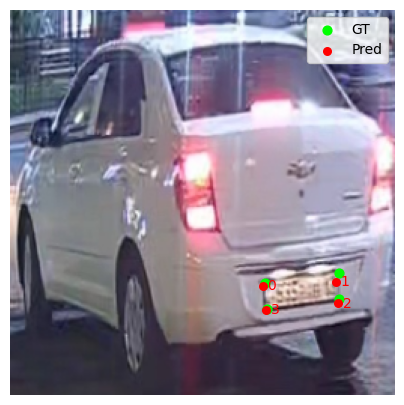

In [65]:
import matplotlib.pyplot as plt
import cv2

imgs, kps = next(iter(val_loader))
imgs = imgs.to(device)
with torch.no_grad():
    preds = model(imgs).cpu().numpy()

imgs = imgs.cpu().numpy()  # [B,C,H,W]
for i in range(min(6, imgs.shape[0])):
    img = np.transpose(imgs[i], (1,2,0))  # H,W,C, values [0..1] or normalized
    pred = preds[i].reshape(-1,2) * img_size
    gt = kps[i].numpy().reshape(-1,2) * img_size

    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.scatter(gt[:,0], gt[:,1], c='lime', s=40, label='GT')
    plt.scatter(pred[:,0], pred[:,1], c='red',  s=30, label='Pred')
    for j,(x,y) in enumerate(pred):
        plt.text(x+3, y+3, str(j), color='red')
    plt.legend()
    plt.axis('off')
    plt.show()